# 07 · Profundización: pronóstico de demanda con validación temporal

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Profundización y apoyo a CE 2.3 (modelo de series de tiempo) · pregrado avanzado y postgrado.**
Construirás pronósticos mensuales con referencias ingenuas y una regresión de tendencia y estacionalidad, los evaluarás con origen móvil (nunca con partición aleatoria) y estimarás intervalos empíricos por horizonte.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

### Antes de ejecutar

Profundización · 120 min guiados + 45 min autónomos orientativos.

**Objetivo:** Evaluar una serie mediante orígenes móviles y referencias comparables.

**Preparación:** Validación temporal, tendencia, estacionalidad y MAE.

**Ejemplo de referencia:** QuillayMarket: comparar pronóstico estacional y modelo con variables temporales.

**Práctica:** Aumentar el horizonte y analizar cobertura y MASE sin ajustar con los meses de prueba.

**Criterio de logro:** Explicar horizonte, cobertura observada, referencia y límites de cambios del proceso.

**Distribución orientativa:** explicación 35 min; práctica guiada 85 min; trabajo autónomo 45 min. Ajustar tras una clase piloto.

[Guía y secuencia](../guia_maestra_mpn.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/MPN_manual_cientifico.html#sec-series)

In [1]:
from pathlib import Path
import sys
import warnings

RAIZ = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "_transversal" / "datos").is_dir()), None
)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "font.size": 10,
    }
)
pd.set_option("display.max_columns", 16)
pd.set_option(
    "display.float_format",
    lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}",
)
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


<a id="serie"></a>

## Serie simulada con el perfil estacional de QuillayMarket

El archivo de QuillayMarket contiene doce meses sin año. Para estudiar pronóstico se **simula** una serie mensual de
seis años (2020–2025) que reproduce el perfil estacional observado —noviembre y diciembre altos—, una tendencia
moderada y ruido. El mecanismo es conocido solo porque es una simulación; en un caso real la serie provendría del
sistema de ventas.

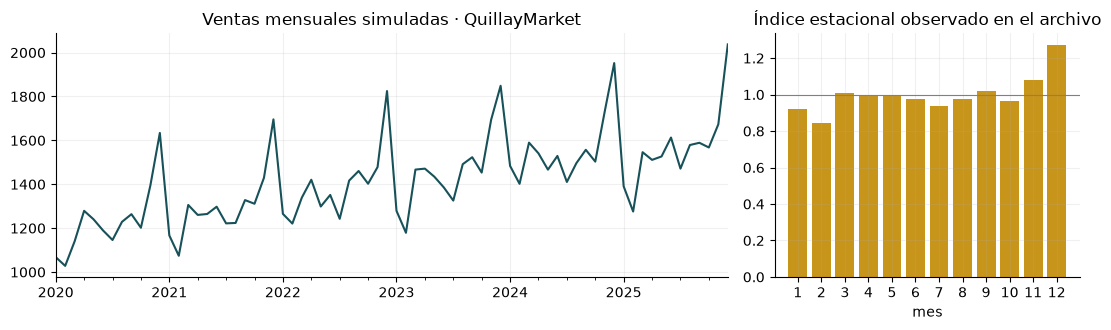

In [2]:
demanda = mr.quillaymarket_demanda()
perfil = demanda.groupby("mes")["ventas_unidades"].mean()
indice_estacional = (perfil / perfil.mean()).to_numpy()
g = np.random.default_rng(SEMILLA)
fechas = pd.period_range("2020-01", "2025-12", freq="M")
t = np.arange(len(fechas))
nivel = 1200 + 6 * t  # tendencia simulada (unidades totales por mes)
serie = pd.Series(
    nivel * indice_estacional[fechas.month - 1] + g.normal(0, 45, len(t)),
    index=fechas,
    name="unidades",
)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
serie.plot(ax=ejes[0], color="#175159", title="Ventas mensuales simuladas · QuillayMarket")
ejes[1].bar(range(1, 13), indice_estacional, color="#c8951b")
ejes[1].axhline(1, color="grey", lw=0.8)
ejes[1].set(title="Índice estacional observado en el archivo", xlabel="mes", xticks=range(1, 13))
plt.tight_layout()
plt.show()

<a id="referencias"></a>

## Referencias ingenuas: el estándar mínimo

- **Ingenuo:** el próximo mes será igual al último observado.
- **Ingenuo estacional:** cada mes será igual al mismo mes del año anterior.
- **Media:** el promedio histórico.

Un método sofisticado que no supera al ingenuo estacional no aporta valor. La métrica **MASE** divide el error del
método por el error medio del ingenuo estacional dentro de entrenamiento. MASE < 1 significa error menor que esa escala histórica; para demostrar mejora predictiva se comparan ambos métodos en los mismos orígenes y horizontes futuros.

In [3]:
from sklearn.linear_model import LinearRegression


def pronosticar(historia, horizonte, metodo):
    pasos = np.arange(1, horizonte + 1)
    if metodo == "Ingenuo":
        return np.repeat(historia.iloc[-1], horizonte)
    if metodo == "Ingenuo estacional":
        return np.array([historia.iloc[-12 + (h - 1) % 12] for h in pasos])
    if metodo == "Media":
        return np.repeat(historia.mean(), horizonte)
    # Regresión con tendencia lineal y meses como indicadores
    meses = historia.index.month
    X_h = pd.get_dummies(
        pd.Categorical(meses, categories=range(1, 13)), prefix="mes", drop_first=True, dtype=float
    )
    X_h.insert(0, "t", np.arange(len(historia)))
    modelo = LinearRegression().fit(X_h, historia.to_numpy())
    futuro = pd.period_range(historia.index[-1] + 1, periods=horizonte, freq="M")
    X_f = pd.get_dummies(
        pd.Categorical(futuro.month, categories=range(1, 13)),
        prefix="mes",
        drop_first=True,
        dtype=float,
    )
    X_f.insert(0, "t", np.arange(len(historia), len(historia) + horizonte))
    return modelo.predict(X_f)


METODOS = ["Ingenuo", "Ingenuo estacional", "Media", "Tendencia + estacionalidad"]

<a id="validacion-temporal"></a>

## Validación con origen móvil

Con datos temporales, una partición aleatoria mezcla pasado y futuro: el modelo aprendería de meses posteriores a
los que predice. La **validación con origen móvil** usa la historia hasta el mes $T$, pronostica $T+1,\dots,T+h$,
avanza un mes y repite. Cada pronóstico se evalúa solo con información anterior a su origen.

,MAE,MAPE_%,MASE
método,,,
Tendencia + estacionalidad,48.451,3.277,0.591
Ingenuo estacional,80.780,5.362,0.992
Ingenuo,161.003,10.713,1.974
Media,181.069,11.295,2.215


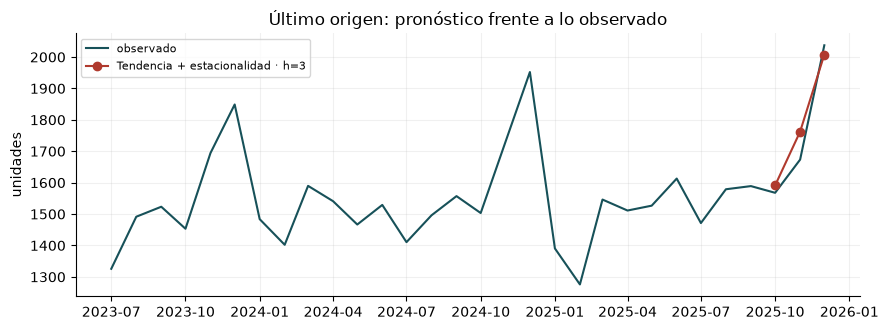

interactive(children=(IntSlider(value=3, description='horizonte', max=12, min=1), Dropdown(description='metodo…

<function __main__.explorar_pronostico(horizonte=3, metodo='Tendencia + estacionalidad')>

In [4]:
def origen_movil(horizonte=3, primer_origen=36):
    errores = []
    for origen in range(primer_origen, len(serie) - horizonte + 1):
        historia, real = serie.iloc[:origen], serie.iloc[origen : origen + horizonte].to_numpy()
        escala = np.mean(np.abs(historia.iloc[12:].to_numpy() - historia.iloc[:-12].to_numpy()))
        for metodo in METODOS:
            e = real - pronosticar(historia, horizonte, metodo)
            errores.append(
                {
                    "método": metodo,
                    "origen": origen,
                    "MAE": np.mean(np.abs(e)),
                    "MAPE_%": np.mean(np.abs(e / real)) * 100,
                    "MASE": np.mean(np.abs(e)) / escala,
                    "error_ultimo_paso": e[-1],
                }
            )
    return pd.DataFrame(errores)


def explorar_pronostico(horizonte=3, metodo="Tendencia + estacionalidad"):
    resultados = origen_movil(horizonte)
    tabla = resultados.groupby("método")[["MAE", "MAPE_%", "MASE"]].mean().sort_values("MASE")
    display(tabla)
    historia = serie.iloc[:-horizonte]
    pron = pronosticar(historia, horizonte, metodo)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    observado = serie.iloc[-30:]
    ax.plot(
        observado.index.to_timestamp(), observado.to_numpy(), color="#175159", label="observado"
    )
    ax.plot(
        serie.index[-horizonte:].to_timestamp(),
        pron,
        marker="o",
        color="#b03a2e",
        label=f"{metodo} · h={horizonte}",
    )
    ax.set(title="Último origen: pronóstico frente a lo observado", ylabel="unidades")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return tabla


pronostico_base = explorar_pronostico()
widgets.interact(
    explorar_pronostico,
    horizonte=widgets.IntSlider(value=3, min=1, max=12, description="horizonte"),
    metodo=widgets.Dropdown(options=METODOS, value="Tendencia + estacionalidad"),
)

**Lectura.** El ingenuo y la media ignoran la estacionalidad y fallan en noviembre y diciembre. El ingenuo
estacional es una referencia exigente; la regresión con tendencia y meses lo supera porque además aprovecha la
tendencia y promedia el ruido de varios años. Al aumentar el horizonte el error crece: comprometer compras con 12
meses de anticipación exige aceptar más incertidumbre.

<a id="intervalos"></a>

## Intervalos empíricos por horizonte

Los errores de origen móvil del último paso permiten construir un intervalo empírico: si $q_{0,9}$ es el cuantil 90%
de $|e|$ en horizonte $h$, el pronóstico $\hat y \pm q_{0,9}$ cubre aproximadamente 90% de los meses, **si** el
proceso futuro se parece al histórico. Se fija una primera fecha de emisión para verificar.
Solo se usan errores cuyo resultado objetivo ocurrió **antes** de esa fecha; no basta separar orígenes por mitades.
El método tendencia + estacionalidad está fijado para esta demostración. La comparación retrospectiva de métodos
no se presenta como una prueba final independiente de una selección hecha con esos mismos resultados.


In [5]:
filas = []
for h in [1, 3, 6]:
    resultados = origen_movil(h)
    r = (
        resultados[resultados["método"] == "Tendencia + estacionalidad"]
        .sort_values("origen")
        .copy()
    )
    r["objetivo"] = r["origen"] + h - 1
    primer_origen_verificacion = int(r["origen"].iloc[len(r) // 2])
    calibracion = r[r["objetivo"] < primer_origen_verificacion]
    verificacion = r[r["origen"] >= primer_origen_verificacion]
    assert len(calibracion) > 0 and len(verificacion) > 0
    assert calibracion["objetivo"].max() < verificacion["origen"].min()
    q90 = float(np.quantile(np.abs(calibracion["error_ultimo_paso"]), 0.9, method="higher"))
    cobertura = float(np.mean(np.abs(verificacion["error_ultimo_paso"]) <= q90))
    filas.append(
        {
            "horizonte": h,
            "semiancho_90 (unidades)": q90,
            "cobertura en orígenes posteriores": cobertura,
            "errores de calibración disponibles": len(calibracion),
            "último resultado de calibración": str(serie.index[int(calibracion.objetivo.max())]),
            "primera emisión": str(serie.index[primer_origen_verificacion]),
            "orígenes de verificación": len(verificacion),
        }
    )
intervalos = pd.DataFrame(filas).set_index("horizonte")
display(intervalos)

,semiancho_90 (unidades),cobertura en orígenes posteriores,errores de calibración disponibles,último resultado de calibración,primera emisión,orígenes de verificación
horizonte,,,,,,
1,94.056,0.833,18,2024-06,2024-07,18
3,99.526,0.824,15,2024-05,2024-06,17
6,107.789,0.812,10,2024-03,2024-04,16


**Lectura crítica.** La tabla informa la cobertura realmente observada y cuántos errores estaban disponibles.
Con pocos errores, el cuantil es inestable y puede dar intervalos demasiado estrechos o anchos.
Los pronósticos comparten historia y los errores pueden estar correlacionados: no aplicamos sin justificación
un error estándar binomial de observaciones independientes. La cobertura nominal de 90% es una referencia empírica,
no una garantía conformal. Si se elige el método mirando estos backtests, se necesita otra ventana futura reservada
para evaluar esa selección. No se ajusta el ancho para forzar 90% en los resultados de verificación.


### Ejercicios resueltos

1. **¿Por qué no `train_test_split` aleatorio?** Porque el modelo usaría meses futuros para predecir meses pasados;
   el error estimado sería optimista y no reproducible en operación.
2. **MASE = 0,8.** El método comete 20% menos error absoluto que el ingenuo estacional en la muestra de escala.
3. **Quiebre estructural.** Si en 2024 cambió la política de precios, conviene ponderar más la historia reciente o
   agregar una variable de régimen, y revisar si los intervalos siguen cubriendo.
4. **Horizonte.** ¿Debe el semiancho crecer siempre con $h$? No necesariamente en una muestra finita. La incertidumbre de tendencia puede acumularse y hay menos
   información reciente sobre los meses lejanos.

**Extensión de postgrado:** suavizamiento exponencial (Holt-Winters), modelos ARIMA/SARIMA con variables exógenas
(precio, promociones), pronóstico jerárquico por categoría y evaluación probabilística con puntajes de cuantiles.

In [6]:
auto_07 = pregunta(
    "Para evaluar un pronóstico mensual, ¿qué partición corresponde?",
    [
        "Aleatoria estratificada por mes",
        "Origen móvil: entrenar con el pasado y evaluar en meses posteriores",
        "Validación cruzada aleatoria de 10 pliegues",
    ],
    1,
    "El tiempo tiene dirección: cada pronóstico debe usar solo información anterior a su origen.",
)
tabla_h3 = pronostico_base
assert (
    tabla_h3.loc["Tendencia + estacionalidad", "MASE"]
    < tabla_h3.loc["Ingenuo estacional", "MASE"]
    <= tabla_h3.loc["Media", "MASE"]
)
assert (intervalos["semiancho_90 (unidades)"] > 0).all()
assert (
    intervalos["cobertura en orígenes posteriores"].between(0, 1).all()
)  # No imponer desempeño al simulador.
print("Comprobaciones del laboratorio 07: OK")

Comprobaciones del laboratorio 07: OK


### Referencias

Hyndman y Athanasopoulos, *Forecasting: Principles and Practice*, 3.ª ed. (OTexts, 2021),
[otexts.com/fpp3](https://otexts.com/fpp3/) (capítulos 5 y 7) · Hyndman y Koehler, «Another look at measures of
forecast accuracy», *International Journal of Forecasting* 22(4) (2006), para MASE.

## Práctica de transferencia 07

Al emitir en abril solo se observan resultados hasta marzo. Un error de pronóstico tiene objetivo abril y otro marzo. Decide cuáles pueden calibrar el intervalo y escribe una condición con fechas. Explica el límite de usar el mismo backtest para escoger y evaluar el método.

**Entrega:** hipótesis previa, cálculo con unidades, interpretación y límite. Completa tu respuesta antes de consultar la [pauta docente](../material_propio/PAUTA_DOCENTE.md#nb07).

**Discusión:** ¿Cómo incorporarías retrasos en la llegada de etiquetas?

### Tu resolución

Edita esta celda: escribe tu hipótesis, procedimiento, resultado, interpretación y una comprobación. Adjunta tu código o gráfico si la actividad lo requiere.

**Auto-revisión:** ¿usé la población correcta?, ¿declaré unidades y supuestos?, ¿mi evidencia permite esa conclusión?